# Bibliotecas

In [1]:
# Configurações gerais
import warnings

warnings.filterwarnings("ignore")

# Manipulação de dados
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo
from xgboost import XGBClassifier

# Validação e seleção de modelos
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# Variáveis declaradas

In [2]:
melhores_parametros =  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 0.1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}

qtd_classes = 7

semente = 42

colunas_input = [
    'Age',
    'BMI',
    'CAEC_freq',
    'CALC_freq',
    'FCVC',
    'flag_female',
    'flag_family_history',
    'MTRANS_Public_Transportation'
]

# Funções

In [3]:
def score_combinado(estimator, X, y):
    y_pred = estimator.predict(X)
    y_proba = estimator.predict_proba(X)

    auc = roc_auc_score(
        y,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    sensibilidade = recall_score(
        y,
        y_pred,
        average="macro"
    )

    return 0.4 * auc + 0.6 * sensibilidade

In [4]:
def calcular_metricas(nome, y_true, y_pred, y_proba):
    y_true = y_true.squeeze()

    return {
        "Conjunto": nome,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision macro": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 macro": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "Sensibilidade macro": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "ROC AUC OVR macro": roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average="macro"
        )
    }

In [38]:
def matriz_confusao_obsidade(conjunto, model, y_real, y_pred):

    classes = model.classes_

    cm_absoluta = confusion_matrix(
        y_real.squeeze(),
        y_pred,
        labels=classes
    )

    cm_normalizada = confusion_matrix(
        y_real.squeeze(),
        y_pred,
        labels=classes,
        normalize="true"
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    sns.heatmap(
        cm_absoluta,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[0]
    )

    axes[0].set_title(f"Matriz de confusão — {conjunto}")
    axes[0].set_xlabel("Classe predita")
    axes[0].set_ylabel("Classe real")

    sns.heatmap(
        cm_normalizada,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[1]
    )

    axes[1].set_title("Matriz normalizada por classe real")
    axes[1].set_xlabel("Classe predita")
    axes[1].set_ylabel("Classe real")

    plt.tight_layout()
    plt.show()

In [6]:
## Criando Features
def create_features(df):
    df = df.copy()

    cols_to_round = ["FCVC"]

    for col in cols_to_round:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    df["flag_female"] = df["Gender"].map({"Female": 1, "Male": 0})
    df = df.drop(columns=["Gender"])

    df["flag_family_history"] = df["family_history"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["family_history"])

    mapa_frequencia = {
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }

    df["CAEC_freq"] = df["CAEC"].map(mapa_frequencia)
    df["CALC_freq"] = df["CALC"].map(mapa_frequencia)

    df = df.drop(columns=["CAEC", "CALC"])

    colunas_categoricas = ["MTRANS"]

    df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)

    # IMC
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

    return df

# Exemplo: df_fe = create_features(df)

# Importando as bases

In [15]:
output_dir = "bases_preparadas"

# Treinamento
X_train_xgb = pd.read_csv(f"{output_dir}/X_train.csv")
y_train_xgb = pd.read_csv(f"{output_dir}/y_train.csv")

# Validação
X_val_xgb = pd.read_csv(f"{output_dir}/X_val.csv")
y_val_xgb = pd.read_csv(f"{output_dir}/y_val.csv")

# Teste
X_test_xgb = pd.read_csv(f"{output_dir}/X_test.csv")
y_test_xgb = pd.read_csv(f"{output_dir}/y_test.csv")

In [17]:
X_train_xgb = create_features(X_train_xgb)
X_val_xgb = create_features(X_val_xgb)
X_test_xgb = create_features(X_test_xgb)

X_train_xgb = X_train_xgb[colunas_input].copy()
X_val_xgb = X_val_xgb[colunas_input].copy()
X_test_xgb = X_test_xgb[colunas_input].copy()

# Treinando o modelo

In [18]:
display("Hiperparametros de modelagem: ", melhores_parametros)

# Técnica de modelagem
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=qtd_classes,
    eval_metric="mlogloss",
    random_state=semente,
    n_jobs=-1,
    **melhores_parametros
)

'Hiperparametros de modelagem: '

{'colsample_bytree': 0.8,
 'gamma': 0,
 'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 0.1,
 'n_estimators': 200,
 'reg_lambda': 1,
 'subsample': 0.8}

In [20]:
# Base de dados é pequena, então faremos KFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_cv = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "f1_macro": "f1_macro",
    "sensibilidade_macro": "recall_macro",
    "roc_auc_ovr_macro": "roc_auc_ovr"
}

resultado_cv = cross_validate(
    estimator=xgb,
    X=X_train_xgb,
    y=y_train_xgb.squeeze(),
    cv=cv,
    scoring=metricas_cv,
    return_train_score=True,
    n_jobs=-1
)

In [21]:
resultados_kfold = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision macro",
        "F1 macro",
        "Sensibilidade macro",
        "ROC AUC OVR macro"
    ],
    "Treino - média": [
        resultado_cv["train_accuracy"].mean(),
        resultado_cv["train_precision_macro"].mean(),
        resultado_cv["train_f1_macro"].mean(),
        resultado_cv["train_sensibilidade_macro"].mean(),
        resultado_cv["train_roc_auc_ovr_macro"].mean()
    ],
    "Validação CV - média": [
        resultado_cv["test_accuracy"].mean(),
        resultado_cv["test_precision_macro"].mean(),
        resultado_cv["test_f1_macro"].mean(),
        resultado_cv["test_sensibilidade_macro"].mean(),
        resultado_cv["test_roc_auc_ovr_macro"].mean()
    ],
}).set_index("Métrica")

display(resultados_kfold.round(4))

,Treino - média,Validação CV - média
Métrica,,
Accuracy,0.9998,0.9774
Precision macro,0.9998,0.9777
F1 macro,0.9998,0.9769
Sensibilidade macro,0.9999,0.9768
ROC AUC OVR macro,1.0000,0.9990


In [22]:
xgb_fit = xgb.fit(
    X_train_xgb, 
    y_train_xgb.squeeze()
)

# Importancia das variáveis

In [23]:
feature_importance_xgb = pd.DataFrame({
    "feature": X_train_xgb.columns,
    "importance": xgb_fit.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_xgb)

,feature,importance
1,BMI,0.476074
5,flag_female,0.188548
4,FCVC,0.084598
6,flag_family_history,0.072053
2,CAEC_freq,0.064357
3,CALC_freq,0.053007
7,MTRANS_Public_Transportation,0.032067
0,Age,0.029295


# Predição

In [24]:
y_train_pred = xgb.predict(X_train_xgb)
y_train_proba = xgb.predict_proba(X_train_xgb)

y_val_pred = xgb.predict(X_val_xgb)
y_val_proba = xgb.predict_proba(X_val_xgb)

y_test_pred = xgb.predict(X_test_xgb)
y_test_proba = xgb.predict_proba(X_test_xgb)

In [26]:
resultados = [
    calcular_metricas(
        "Treino",
        y_train_xgb,
        y_train_pred,
        y_train_proba
    ),
    calcular_metricas(
        "Validação",
        y_val_xgb,
        y_val_pred,
        y_val_proba
    ),
    calcular_metricas(
        "Teste",
        y_test_xgb,
        y_test_pred,
        y_test_proba
    )
]

tabela_metricas = (
    pd.DataFrame(resultados)
    .set_index("Conjunto")
    .round(3)
)

display(tabela_metricas)

,Accuracy,Precision macro,F1 macro,Sensibilidade macro,ROC AUC OVR macro
Conjunto,,,,,
Treino,1.000,1.000,1.000,1.000,1.000
Validação,0.962,0.962,0.961,0.961,0.997
Teste,0.968,0.969,0.967,0.967,0.998


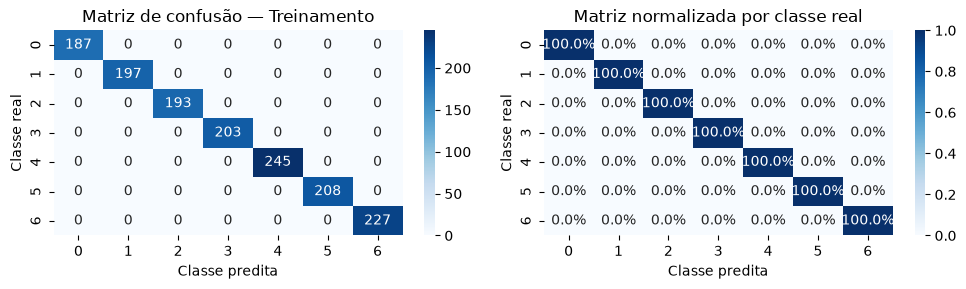

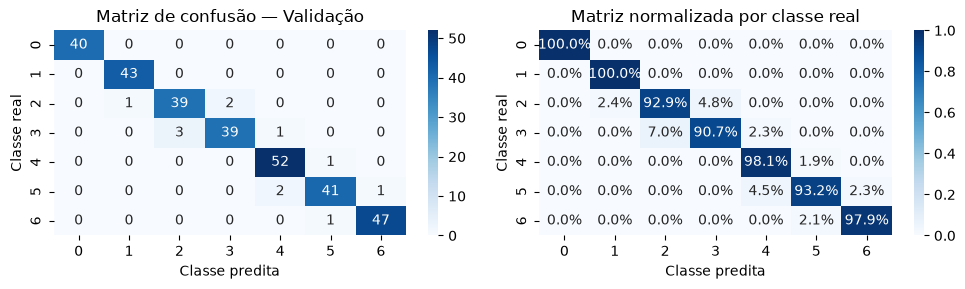

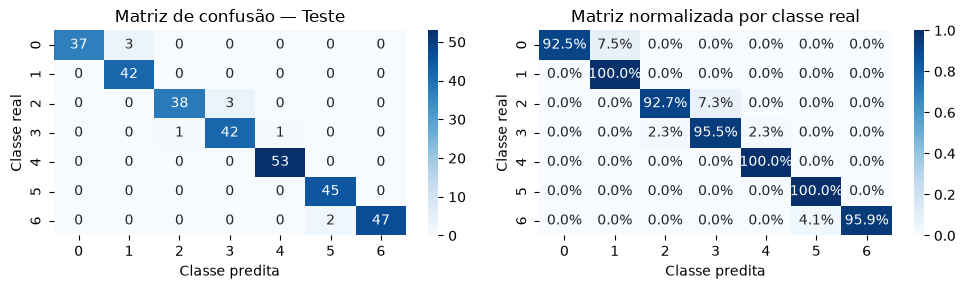

In [43]:
matriz_confusao_obsidade("Treinamento", xgb, y_train_xgb, y_train_pred)
matriz_confusao_obsidade("Validação", xgb, y_val_xgb, y_val_pred)
matriz_confusao_obsidade("Teste", xgb, y_test_xgb, y_test_pred)

# Informações para Pickle

In [ ]:
colunas_fillna = {
    'Age': 23,
    'Height' : 1.7,
    'CAEC' : 'Sometimes',
    'CALC' : 'Sometimes',
    'Gender' : "Female",
    'FCVC': 2,
    'MTRANS' : 'Public_Transportation'
}

target_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}

In [46]:
import joblib

artefato_modelo = {
    "modelo": xgb,
    "target_map": target_map,
    "colunas_input": colunas_input,
    "melhores_parametros": melhores_parametros,
    "valores_fillna": colunas_fillna,
    "feature_importance": feature_importance_xgb,
    "metricas_treinamento": tabela_metricas,

    "dados": {
        "X_train": X_train_xgb,
        "y_train": y_train_xgb,
        "X_validation": X_val_xgb,
        "y_validation": y_val_xgb,
        "X_test": X_test_xgb,
        "y_test": y_test_xgb
    }
}

joblib.dump(
    artefato_modelo,
    "modelo_xgboost_obesidade.joblib",
    compress=3
)

['modelo_xgboost_obesidade.joblib']

In [10]:
import joblib
import pandas as pd

artefato_carregado = joblib.load(
    "modelo_xgboost_obesidade.joblib"
)

modelo = artefato_carregado["modelo"]
target_map = artefato_carregado["target_map"]
colunas_input = artefato_carregado["colunas_input"]
melhores_parametros = artefato_carregado["melhores_parametros"]
valores_fillna = artefato_carregado["valores_fillna"]
feature_importance = artefato_carregado["feature_importance"]
metricas = artefato_carregado["metricas_treinamento"]
dados = artefato_carregado["dados"]

['modelo_xgboost_obesidade.joblib']